# MSIS 522 HW1 — Flaredown Food & Flare Prediction
**Author:** Hannah  
**Date:** March 2026  
**Dataset:** [Flaredown Autoimmune Symptom Tracker](https://www.kaggle.com/datasets/flaredown/flaredown-autoimmune-symptom-tracker)  

---

## 1.0 Dataset Introduction

### What does the dataset contain and where did it come from?

The **Flaredown dataset** is a publicly available export from [Flaredown](https://flaredown.com/), a free community-driven symptom tracker used by people with chronic illnesses (autoimmune conditions, chronic pain, etc.). It is hosted on Kaggle and contains **~8 million rows** in a long/melted format — each row records a single "trackable" observation for one user on one day.

The raw fields are:
- **user_id** — anonymized/hashed user identifier
- **checkin_date** — the date of the daily check-in
- **age, sex, country** — user demographics
- **trackable_type** — one of: `Symptom`, `Food`, `Treatment`, `Condition`, `Weather`, `Tag`
- **trackable_name** — e.g., "Pain", "Coffee", "Ibuprofen", "Rainy"
- **trackable_value** — symptom severity (0–4 scale), or presence (1) for foods/treatments

After preprocessing (see `src/data_preprocessing.py`), the dataset was filtered to **104,447 user-days** where users tracked **both food AND symptoms** on the same day, then pivoted into a wide feature matrix with 104 predictive features and 1 binary target.

### What is the prediction target?

**`flare`** (binary: 0 or 1) — A user-day is labeled as a **flare** if the maximum symptom severity reported that day is **≥ 3 on the 0–4 scale**. This threshold was chosen because severity levels 3 and 4 represent "severe" and "unbearable" in the Flaredown interface, reflecting days where symptoms meaningfully impair daily functioning.

### Why is this prediction task interesting or impactful?

As someone living with **hypermobile Ehlers-Danlos Syndrome (hEDS)** and **Postural Orthostatic Tachycardia Syndrome (POTS)**, I know firsthand how much daily choices can influence symptom flares. Millions of people with chronic conditions wonder: *can I predict my bad days based on what I eat, how I sleep, or the weather?* This project uses real patient-reported data to answer that question with statistical rigor — and the answer turns out to be more nuanced than expected (spoiler: lifestyle factors like stress and sleep matter far more than any individual food).

### Basic statistics

See the code cell below for detailed breakdowns. At a high level:
- **Rows:** 104,447 user-days
- **Features:** 104 (all used for prediction)
- **Target:** `flare` — 68.4% positive (imbalanced toward flare days)
- **Train/Test split:** 70/30 stratified (73,112 / 31,335)

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
import xgboost as xgb
import joblib

# Explainability
import shap

# Paths
PROJECT_DIR = Path('..').resolve()
DATA_DIR = PROJECT_DIR / 'data'
MODELS_DIR = PROJECT_DIR / 'models'
FIGURES_DIR = PROJECT_DIR / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Plot style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete!')

Setup complete!


## Load Processed Data

The raw Flaredown CSV (~686 MB, ~8M rows) was preprocessed using `src/data_preprocessing.py`, which:
1. Loaded the raw long-format data (one row per trackable observation per user per day)
2. Filtered to **user-days where users tracked both food AND symptoms** (~104K rows)
3. Pivoted into a wide feature matrix: top 50 individual foods (binary), 6 food category rollups, 20 treatments, 15 lifestyle tags, weather conditions, and demographics
4. Defined the binary target: `flare = 1` if max symptom severity ≥ 3 on that day
5. Performed a 70/30 stratified train/test split (`random_state=42`)

In [2]:
# Load processed data
df = pd.read_parquet(DATA_DIR / 'processed.parquet')
feature_cols = pd.read_csv(DATA_DIR / 'feature_cols.csv', header=None)[0].tolist()

# Load train/test splits
X_train = pd.read_parquet(DATA_DIR / 'X_train.parquet')
X_test = pd.read_parquet(DATA_DIR / 'X_test.parquet')
y_train = pd.read_parquet(DATA_DIR / 'y_train.parquet')['flare']
y_test = pd.read_parquet(DATA_DIR / 'y_test.parquet')['flare']

print(f'Dataset shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\nFlare rate: {df["flare"].mean():.1%}')
df.head()

Dataset shape: (104447, 108)
Features: 104
Train: 73,112 | Test: 31,335

Flare rate: 68.4%


,user_id,checkin_date,max_symptom_severity,flare,food_coffee,food_water,food_tea,food_chocolate,food_milk,food_sugar,...,tag_gluten,tag_had_sex,tag_bad_sleep,tag_exhausted,tag_worked,tag_went_to_work,tag_poor_sleep,age,sex_female,country_us
0,QEVuQwEA5hkzTOaPksnHJZZjyHW/Ww==,2017-03-16,3,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,50.0,1.0,1
1,QEVuQwEAls3goJ2eZ9lCTdLGUAE5Wg==,2019-04-13,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,44.0,0.0,1
2,QEVuQwEA39gcq8BrtdzGE9gPIHS2mA==,2017-02-04,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38.0,1.0,0
3,QEVuQwEA39gcq8BrtdzGE9gPIHS2mA==,2017-07-31,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38.0,1.0,0
4,QEVuQwEAI5iLLp4TimNZtF+VqW1UXA==,2018-12-16,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,32.0,1.0,0


In [3]:
# === Dataset Basic Statistics ===
print(f'{"="*60}')
print(f'DATASET OVERVIEW')
print(f'{"="*60}')
print(f'Total rows (user-days):     {len(df):,}')
print(f'Total columns:              {df.shape[1]}')
print(f'Predictive features:        {len(feature_cols)}')
print(f'Target variable:            flare (binary)')
print(f'Flare rate (% positive):    {df["flare"].mean():.1%}')
print(f'Unique users:               {df["user_id"].nunique():,}')
print(f'Date range:                 {df["checkin_date"].min()} to {df["checkin_date"].max()}')

print(f'\n{"="*60}')
print(f'FEATURE TYPE BREAKDOWN')
print(f'{"="*60}')

# Classify features
binary_features = [c for c in feature_cols if df[c].dropna().isin([0, 1]).all()]
numerical_features = [c for c in feature_cols if c not in binary_features]

food_feats = [c for c in feature_cols if c.startswith('food_') and not c.startswith('foodcat_')]
foodcat_feats = [c for c in feature_cols if c.startswith('foodcat_')]
treat_feats = [c for c in feature_cols if c.startswith('treat_')]
tag_feats = [c for c in feature_cols if c.startswith('tag_')]
weather_feats = [c for c in feature_cols if c.startswith('weather_')]
demo_feats = [c for c in feature_cols if c in ['age', 'sex_female', 'country_us']]

print(f'\nBy type:')
print(f'  Binary (0/1) features:    {len(binary_features)}')
print(f'  Numerical features:       {len(numerical_features)}  ({", ".join(numerical_features)})')

print(f'\nBy category:')
print(f'  Individual foods:         {len(food_feats)}')
print(f'  Food categories (rollup): {len(foodcat_feats)}')
print(f'  Treatments:               {len(treat_feats)}')
print(f'  Lifestyle tags:           {len(tag_feats)}')
print(f'  Weather:                  {len(weather_feats)}')
print(f'  Demographics:             {len(demo_feats)}')
print(f'  TOTAL:                    {len(feature_cols)}')

print(f'\n{"="*60}')
print(f'TARGET DISTRIBUTION')
print(f'{"="*60}')
print(f'  No Flare (0):  {(df["flare"]==0).sum():>8,}  ({(df["flare"]==0).mean():.1%})')
print(f'  Flare (1):     {(df["flare"]==1).sum():>8,}  ({(df["flare"]==1).mean():.1%})')

print(f'\n{"="*60}')
print(f'TRAIN / TEST SPLIT')
print(f'{"="*60}')
print(f'  Train set: {len(X_train):,} rows ({len(X_train)/len(df):.0%})')
print(f'  Test set:  {len(X_test):,} rows ({len(X_test)/len(df):.0%})')
print(f'  Train flare rate: {y_train.mean():.1%}')
print(f'  Test flare rate:  {y_test.mean():.1%}  (stratified — matches train)')

DATASET OVERVIEW
Total rows (user-days):     104,447
Total columns:              108
Predictive features:        104
Target variable:            flare (binary)
Flare rate (% positive):    68.4%
Unique users:               19,558
Date range:                 2016-12-25 00:00:00 to 2019-12-06 00:00:00

FEATURE TYPE BREAKDOWN

By type:
  Binary (0/1) features:    100
  Numerical features:       4  (weather_humidity, weather_pressure, age, sex_female)

By category:
  Individual foods:         50
  Food categories (rollup): 6
  Treatments:               20
  Lifestyle tags:           15
  Weather:                  10
  Demographics:             3
  TOTAL:                    104

TARGET DISTRIBUTION
  No Flare (0):    32,983  (31.6%)
  Flare (1):       71,464  (68.4%)

TRAIN / TEST SPLIT
  Train set: 73,112 rows (70%)
  Test set:  31,335 rows (30%)
  Train flare rate: 68.4%
  Test flare rate:  68.4%  (stratified — matches train)


---
# Part 1: Descriptive Analytics (25 pts)

## 1.1 Target Distribution

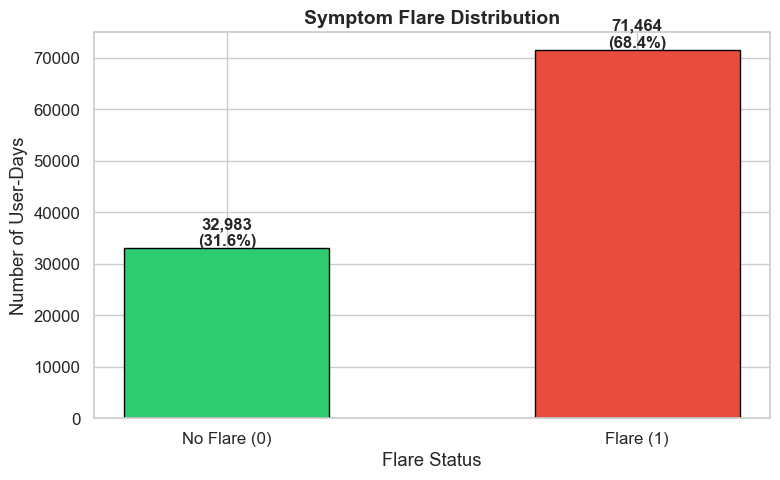

Flare rate: 68.4% — the dataset is imbalanced toward flare days.


In [4]:
# Target Distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['flare'].value_counts().sort_index()
bars = ax.bar(['No Flare (0)', 'Flare (1)'], counts.values, 
              color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
            f'{count:,}\n({count/len(df):.1%})', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Symptom Flare Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of User-Days')
ax.set_xlabel('Flare Status')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Flare rate: {df["flare"].mean():.1%} — the dataset is imbalanced toward flare days.')

**Observations:** The target is **imbalanced** — 68.4% flare days vs. 31.6% no-flare, roughly a 2:1 ratio. This is expected since Flaredown users are people actively managing chronic illnesses, so high-severity days are common. We handle this imbalance with `class_weight='balanced'` on all sklearn models, `scale_pos_weight` on XGBoost, stratified train/test splits, and evaluating on **F1 Score / ROC AUC** rather than raw accuracy (a naive "always predict flare" classifier would achieve 68.4% accuracy).

## 1.2 Top Foods by Frequency

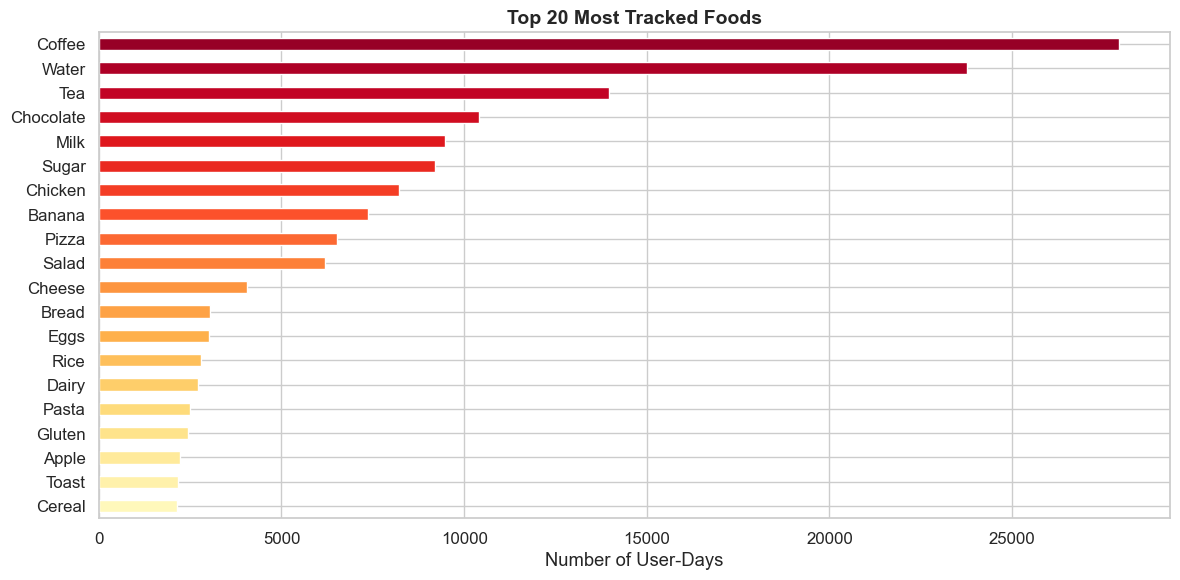

In [5]:
# Top 20 Foods by Frequency
food_cols_only = [c for c in feature_cols if c.startswith('food_') and not c.startswith('foodcat_')]
food_freq = df[food_cols_only].sum().sort_values(ascending=False).head(20)
food_freq.index = [c.replace('food_', '').replace('_', ' ').title() for c in food_freq.index]

fig, ax = plt.subplots(figsize=(12, 6))
food_freq.plot(kind='barh', ax=ax, color=sns.color_palette('YlOrRd_r', len(food_freq)))
ax.set_title('Top 20 Most Tracked Foods', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of User-Days')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_foods_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 What Actually Predicts Flares? Food vs. Lifestyle Factors

The original question was: *which foods trigger flares?* But a rigorous analysis reveals a more important answer.

**Methodological approach:**
1. **Within-user paired comparison** — for each trackable, compare the *same users'* flare rate on days they logged it vs. days they didn't (controls for Simpson's Paradox)
2. **Wilcoxon signed-rank test** — non-parametric test on per-user flare rate differences
3. **Multiple comparison correction** — Bonferroni correction applied within each category (6 food categories, 50 individual foods, 15 tags, 20 treatments)

**Key caveat:** This is observational, self-reported data. Associations are not causation. Many confounders remain (e.g., people may log "stressed" on days that are already bad for other reasons). Sample sizes vary widely. Results should be discussed with a healthcare provider, not used as medical advice.

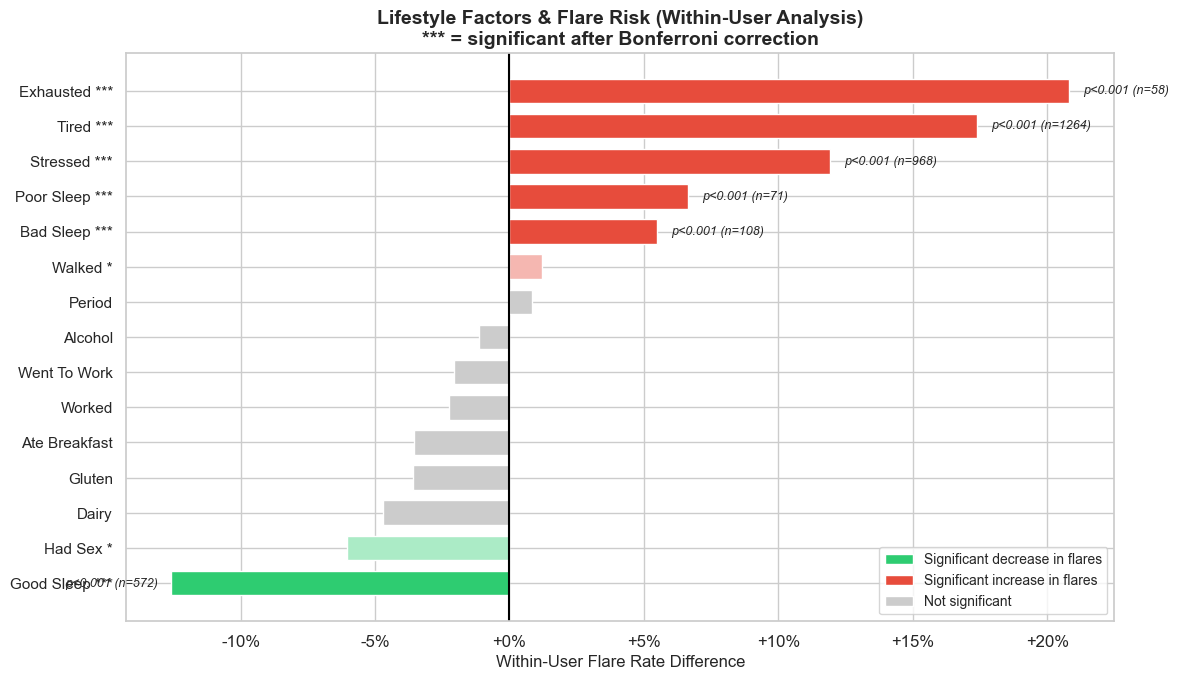

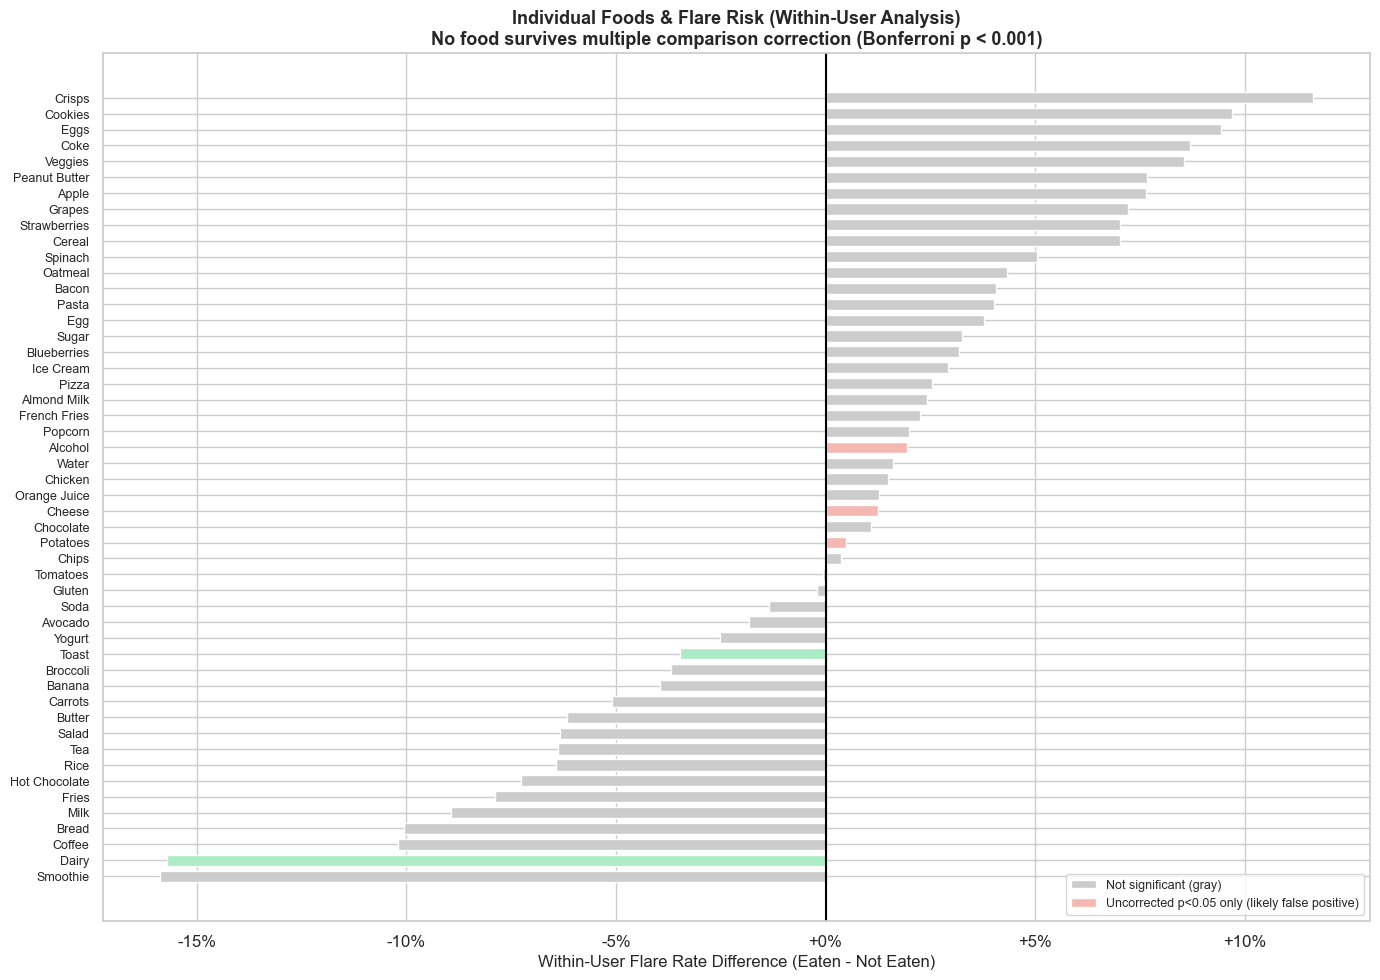


SUMMARY: WHAT ACTUALLY PREDICTS FLARES?

Lifestyle tags with SIGNIFICANT within-user effects (Bonferroni corrected):
  Tired              INCREASES flare rate by 17.4%  (p=0.000000, n=1264 users)
  Stressed           INCREASES flare rate by 11.9%  (p=0.000000, n=968 users)
  Good Sleep         DECREASES flare rate by 12.6%  (p=0.000000, n=572 users)
  Exhausted          INCREASES flare rate by 20.8%  (p=0.000023, n=58 users)
  Poor Sleep         INCREASES flare rate by 6.7%  (p=0.000225, n=71 users)
  Bad Sleep          INCREASES flare rate by 5.5%  (p=0.000631, n=108 users)

Individual foods with significant effects: 0 of 50
  NONE — no individual food survives multiple comparison correction

Conclusion: Stress and sleep quality are FAR stronger predictors of
flares than any individual food. The ML models achieve ~77% AUC by
combining many weak signals, not from any single food.


In [6]:
# Within-User Paired Analysis: Foods, Tags, and Treatments
from scipy.stats import wilcoxon
from matplotlib.patches import Patch

baseline_flare = df['flare'].mean()
food_cols_only = [c for c in feature_cols if c.startswith('food_') and not c.startswith('foodcat_')]
cat_cols = [c for c in feature_cols if c.startswith('foodcat_')]
tag_cols = [c for c in feature_cols if c.startswith('tag_')]
treat_cols = [c for c in feature_cols if c.startswith('treat_')]

def within_user_test(df, col):
    """Run within-user paired flare rate comparison for a binary column."""
    user_on = df[df[col] == 1].groupby('user_id')['flare'].agg(['sum', 'count'])
    user_off = df[df[col] == 0].groupby('user_id')['flare'].agg(['sum', 'count'])
    both = user_on.join(user_off, lsuffix='_on', rsuffix='_off', how='inner')
    both = both[(both['count_on'] >= 3) & (both['count_off'] >= 3)]
    if len(both) < 10:
        return None
    both['diff'] = both['sum_on'] / both['count_on'] - both['sum_off'] / both['count_off']
    pooled_on = both['sum_on'].sum() / both['count_on'].sum()
    pooled_off = both['sum_off'].sum() / both['count_off'].sum()
    nonzero = both['diff'].values[both['diff'].values != 0]
    p = 1.0
    if len(nonzero) >= 10:
        _, p = wilcoxon(nonzero)
    return {
        'within_diff': pooled_on - pooled_off,
        'p_value': p,
        'n_users': len(both),
        'on_days': int(both['count_on'].sum()),
    }

# --- Run analysis for each group ---
all_results = []

# Individual foods (50 tests)
for col in food_cols_only:
    r = within_user_test(df, col)
    if r:
        r['name'] = col.replace('food_', '').replace('_', ' ').title()
        r['group'] = 'Food'
        r['n_tests'] = len(food_cols_only)
        all_results.append(r)

# Food categories (6 tests)
for col in cat_cols:
    r = within_user_test(df, col)
    if r:
        r['name'] = col.replace('foodcat_', '').title() + ' (category)'
        r['group'] = 'Food Category'
        r['n_tests'] = len(cat_cols)
        all_results.append(r)

# Tags (15 tests)
for col in tag_cols:
    r = within_user_test(df, col)
    if r:
        r['name'] = col.replace('tag_', '').replace('_', ' ').title()
        r['group'] = 'Tag / Lifestyle'
        r['n_tests'] = len(tag_cols)
        all_results.append(r)

# Treatments (20 tests) — only include those with enough users
for col in treat_cols:
    r = within_user_test(df, col)
    if r:
        r['name'] = col.replace('treat_', '').replace('_', ' ').title()
        r['group'] = 'Treatment'
        r['n_tests'] = len(treat_cols)
        all_results.append(r)

results_df = pd.DataFrame(all_results)
results_df['bonf_threshold'] = 0.05 / results_df['n_tests']
results_df['sig_corrected'] = results_df['p_value'] < results_df['bonf_threshold']
results_df['sig_uncorrected'] = results_df['p_value'] < 0.05

# Save for Streamlit
results_df.to_csv(DATA_DIR / 'within_user_all_factors.csv', index=False)

# Also save the food-only subset for backward compat
food_only = results_df[results_df['group'] == 'Food'].copy()
food_only.to_csv(DATA_DIR / 'within_user_food_analysis.csv', index=False)

# === PLOT 1: Lifestyle Tags (the big finding) ===
tags_df = results_df[results_df['group'] == 'Tag / Lifestyle'].sort_values('within_diff')

fig, ax = plt.subplots(figsize=(12, 7))
colors_tags = []
for _, row in tags_df.iterrows():
    if row['sig_corrected']:
        colors_tags.append('#e74c3c' if row['within_diff'] > 0 else '#2ecc71')
    elif row['sig_uncorrected']:
        colors_tags.append('#f5b7b1' if row['within_diff'] > 0 else '#abebc6')
    else:
        colors_tags.append('#cccccc')

ax.barh(range(len(tags_df)), tags_df['within_diff'].values, color=colors_tags, edgecolor='white', height=0.7)
ax.set_yticks(range(len(tags_df)))
labels_tags = []
for _, row in tags_df.iterrows():
    star = ''
    if row['sig_corrected']:
        star = ' ***'
    elif row['sig_uncorrected']:
        star = ' *'
    labels_tags.append(f"{row['name']}{star}")
ax.set_yticklabels(labels_tags, fontsize=11)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Within-User Flare Rate Difference', fontsize=12)
ax.set_title('Lifestyle Factors & Flare Risk (Within-User Analysis)\n*** = significant after Bonferroni correction',
             fontsize=14, fontweight='bold')

# Add p-values for significant results
for i, (_, row) in enumerate(tags_df.iterrows()):
    if row['sig_corrected']:
        x = row['within_diff']
        offset = 0.005 if x >= 0 else -0.005
        ha = 'left' if x >= 0 else 'right'
        p_str = f"p<0.001" if row['p_value'] < 0.001 else f"p={row['p_value']:.4f}"
        ax.text(x + offset, i, f"{p_str} (n={row['n_users']})", va='center', ha=ha, fontsize=9, fontstyle='italic')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0%}'))
legend_elements = [
    Patch(facecolor='#2ecc71', label='Significant decrease in flares'),
    Patch(facecolor='#e74c3c', label='Significant increase in flares'),
    Patch(facecolor='#cccccc', label='Not significant'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lifestyle_flare_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# === PLOT 2: Foods (the null result) ===
foods_df = results_df[results_df['group'] == 'Food'].sort_values('within_diff')

fig, ax = plt.subplots(figsize=(14, 10))
colors_food = []
for _, row in foods_df.iterrows():
    if row['sig_corrected']:
        colors_food.append('#e74c3c' if row['within_diff'] > 0 else '#2ecc71')
    elif row['sig_uncorrected']:
        colors_food.append('#f5b7b1' if row['within_diff'] > 0 else '#abebc6')
    else:
        colors_food.append('#cccccc')

ax.barh(range(len(foods_df)), foods_df['within_diff'].values, color=colors_food, edgecolor='white', height=0.7)
ax.set_yticks(range(len(foods_df)))
ax.set_yticklabels(foods_df['name'].values, fontsize=9)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Within-User Flare Rate Difference (Eaten - Not Eaten)', fontsize=12)
ax.set_title('Individual Foods & Flare Risk (Within-User Analysis)\nNo food survives multiple comparison correction (Bonferroni p < 0.001)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0%}'))
legend_food = [
    Patch(facecolor='#cccccc', label='Not significant (gray)'),
    Patch(facecolor='#f5b7b1', label='Uncorrected p<0.05 only (likely false positive)'),
]
ax.legend(handles=legend_food, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'flare_rate_by_food.png', dpi=150, bbox_inches='tight')
plt.show()

# === Summary ===
sig_tags = tags_df[tags_df['sig_corrected']]
sig_foods = foods_df[foods_df['sig_corrected']]
print(f'\n{"="*70}')
print(f'SUMMARY: WHAT ACTUALLY PREDICTS FLARES?')
print(f'{"="*70}')
print(f'\nLifestyle tags with SIGNIFICANT within-user effects (Bonferroni corrected):')
for _, row in sig_tags.sort_values('p_value').iterrows():
    direction = "INCREASES" if row['within_diff'] > 0 else "DECREASES"
    print(f"  {row['name']:18s} {direction} flare rate by {abs(row['within_diff']):.1%}  "
          f"(p={row['p_value']:.6f}, n={row['n_users']} users)")
print(f'\nIndividual foods with significant effects: {len(sig_foods)} of {len(foods_df)}')
if len(sig_foods) == 0:
    print('  NONE — no individual food survives multiple comparison correction')
print(f'\nConclusion: Stress and sleep quality are FAR stronger predictors of')
print(f'flares than any individual food. The ML models achieve ~77% AUC by')
print(f'combining many weak signals, not from any single food.')

## 1.4 Symptom Severity Distribution

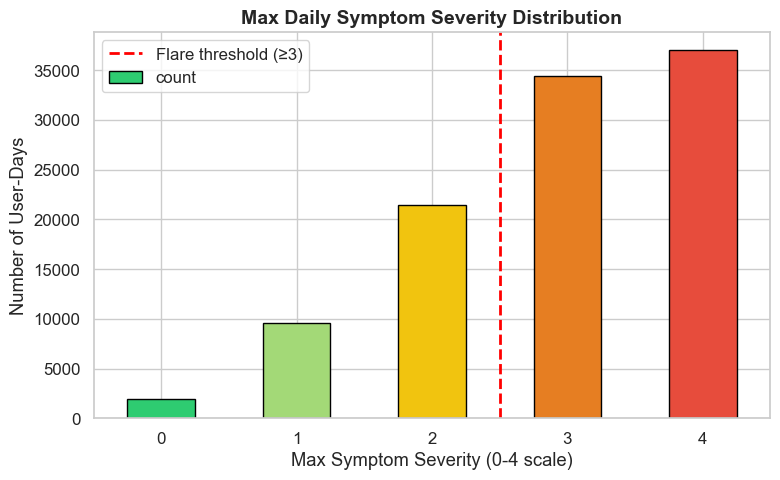

In [7]:
# Symptom Severity Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sev_counts = df['max_symptom_severity'].value_counts().sort_index()
colors_sev = ['#2ecc71', '#a3d977', '#f1c40f', '#e67e22', '#e74c3c']
valid_colors = [colors_sev[int(i)] for i in sev_counts.index if not pd.isna(i) and 0 <= int(i) <= 4]
sev_counts.plot(kind='bar', ax=ax, color=valid_colors[:len(sev_counts)], edgecolor='black')
ax.set_title('Max Daily Symptom Severity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Max Symptom Severity (0-4 scale)')
ax.set_ylabel('Number of User-Days')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='Flare threshold (≥3)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The severity distribution is right-skewed toward the higher end — severity **4 ("unbearable")** is the single most common daily maximum, followed by severity 3. Together, severities 3 and 4 (which define a "flare") account for 68.4% of all user-days. This confirms that Flaredown's user base consists of people actively managing significant chronic illness — most days involve substantial symptoms. The red dashed line marks the flare threshold (≥ 3), making it easy to see why the target is imbalanced toward flare = 1.

## 1.5 Flare Rate by Weather Condition

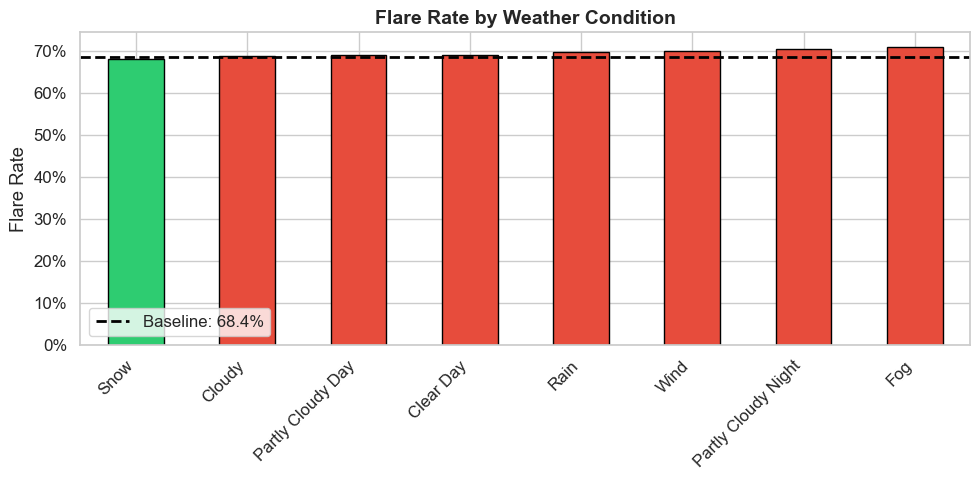

In [8]:
# Flare Rate by Weather Icon
weather_icon_cols = [c for c in feature_cols if c.startswith('weather_icon_')]
if weather_icon_cols:
    weather_flare = {}
    for col in weather_icon_cols:
        name = col.replace('weather_icon_', '').replace('_', ' ').title()
        subset = df[df[col] == 1]
        if len(subset) >= 50:
            weather_flare[name] = subset['flare'].mean()
    
    if weather_flare:
        wf_sr = pd.Series(weather_flare).sort_values()
        fig, ax = plt.subplots(figsize=(10, 5))
        colors_w = ['#2ecc71' if v < baseline_flare else '#e74c3c' for v in wf_sr.values]
        wf_sr.plot(kind='bar', ax=ax, color=colors_w, edgecolor='black')
        ax.axhline(y=baseline_flare, color='black', linestyle='--', linewidth=2, label=f'Baseline: {baseline_flare:.1%}')
        ax.set_title('Flare Rate by Weather Condition', fontsize=14, fontweight='bold')
        ax.set_ylabel('Flare Rate')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'flare_rate_by_weather.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('No weather icon features available.')

**Interpretation:** Weather conditions show only modest variation in flare rate — most conditions hover within a few percentage points of the 68.4% baseline (dashed line). This suggests weather alone is not a strong driver of flares in this dataset. However, this chart compares across users (not within-user), so it may be confounded by geography. The within-user lifestyle analysis above provides much stronger evidence for what actually predicts flares.

## 1.6 Correlation Heatmap

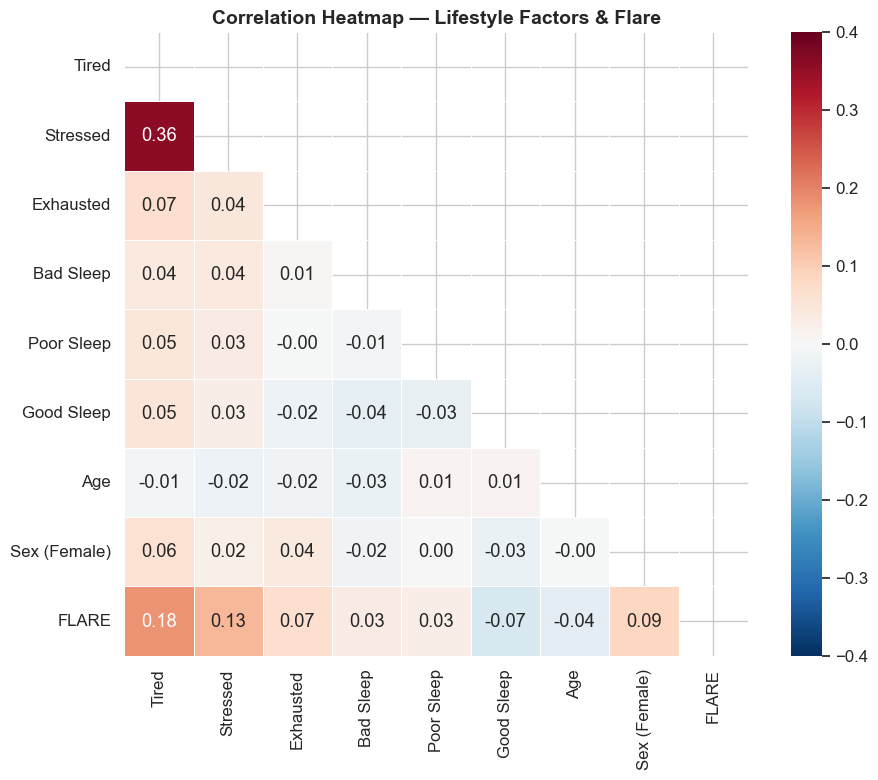

In [9]:
# Correlation Heatmap — Lifestyle Features, Demographics, and Flare
# Focus on the statistically significant lifestyle tags + demographics
heatmap_cols = []
for c in ['tag_tired', 'tag_stressed', 'tag_exhausted', 'tag_bad_sleep',
          'tag_poor_sleep', 'tag_good_sleep', 'age', 'sex_female']:
    if c in feature_cols:
        heatmap_cols.append(c)
heatmap_cols.append('flare')

corr_mat = df[heatmap_cols].corr()

# Clean labels for display
label_map = {
    'tag_tired': 'Tired', 'tag_stressed': 'Stressed', 'tag_exhausted': 'Exhausted',
    'tag_bad_sleep': 'Bad Sleep', 'tag_poor_sleep': 'Poor Sleep',
    'tag_good_sleep': 'Good Sleep', 'age': 'Age', 'sex_female': 'Sex (Female)',
    'flare': 'FLARE',
}
clean_labels = [label_map.get(c, c) for c in heatmap_cols]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=clean_labels, yticklabels=clean_labels, ax=ax,
            vmin=-0.4, vmax=0.4, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Lifestyle Factors & Flare', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**How to read this chart:** Each cell shows the Pearson correlation between two features. **Red = positive correlation** (both increase together), **blue = negative correlation** (one increases as the other decreases), **white = no relationship**. Only the lower triangle is shown since the matrix is symmetric.

**Interpretation:** The strongest correlations with FLARE are Tired (+0.18) and Stressed (+0.13), confirming the within-user analysis. Tired and Stressed also co-occur strongly with each other (+0.36), suggesting a "bad day cluster" where fatigue and stress compound. Good Sleep shows a small negative correlation with flare (-0.07), while Age (-0.04) is weakly protective — older users in this dataset tend to have slightly fewer flare days. The sleep-related tags (Bad Sleep, Poor Sleep) correlate positively with each other and with flare, but more weakly than the fatigue/stress cluster.

## 1.7 Negative Lifestyle Tag Count: Flare vs. No-Flare Days

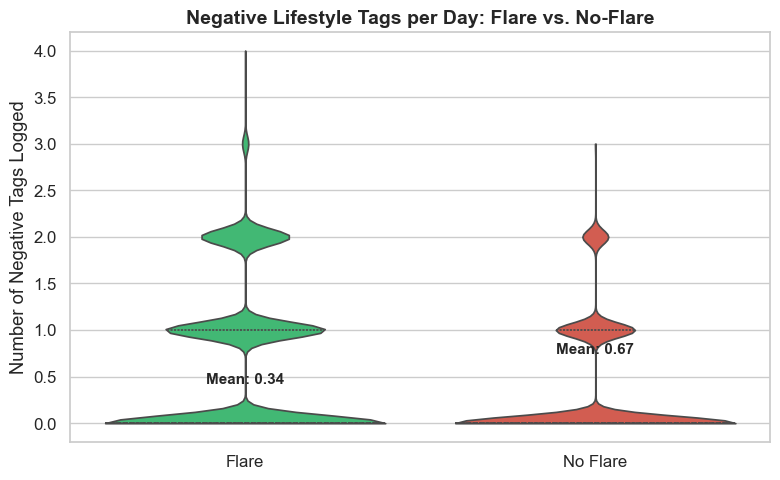

Tags counted: tired, stressed, exhausted, bad_sleep, poor_sleep

No-flare days — mean: 0.34, median: 0
Flare days    — mean: 0.67, median: 0


In [10]:
# Violin Plot — Negative Lifestyle Tag Count by Flare Status
neg_tags = ['tag_tired', 'tag_stressed', 'tag_exhausted', 'tag_bad_sleep', 'tag_poor_sleep']
neg_tags = [c for c in neg_tags if c in feature_cols]

neg_count = df[neg_tags].sum(axis=1)
plot_df = pd.DataFrame({'neg_tag_count': neg_count, 'flare': df['flare']})
plot_df['Flare Status'] = plot_df['flare'].map({0: 'No Flare', 1: 'Flare'})

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=plot_df, x='Flare Status', y='neg_tag_count', ax=ax,
               palette=['#2ecc71', '#e74c3c'], inner='quartile', cut=0)
ax.set_title('Negative Lifestyle Tags per Day: Flare vs. No-Flare', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Negative Tags Logged')
ax.set_xlabel('')

# Add mean annotations
for i, status in enumerate(['No Flare', 'Flare']):
    subset = plot_df[plot_df['Flare Status'] == status]['neg_tag_count']
    mn = subset.mean()
    ax.text(i, mn + 0.08, f'Mean: {mn:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'neg_tags_violin_by_flare.png', dpi=150, bbox_inches='tight')
plt.show()

# Print breakdown
print(f'Tags counted: {", ".join(t.replace("tag_", "") for t in neg_tags)}')
print(f'\nNo-flare days — mean: {neg_count[df["flare"]==0].mean():.2f}, '
      f'median: {neg_count[df["flare"]==0].median():.0f}')
print(f'Flare days    — mean: {neg_count[df["flare"]==1].mean():.2f}, '
      f'median: {neg_count[df["flare"]==1].median():.0f}')

**Interpretation:** This violin plot counts how many negative lifestyle tags (tired, stressed, exhausted, bad sleep, poor sleep) each user logged on a given day, split by flare status. **No-flare days** are overwhelmingly concentrated at **0 negative tags** — these are days where users reported none of the negative states. **Flare days** show a heavier tail toward 1–2+ tags, meaning flare days are more likely to stack multiple bad signals simultaneously. This reinforces the compounding effect: bad days aren't just about one thing going wrong — they tend to involve multiple overlapping stressors.

## 1.8 Flare Rate: Tag Present vs. Absent

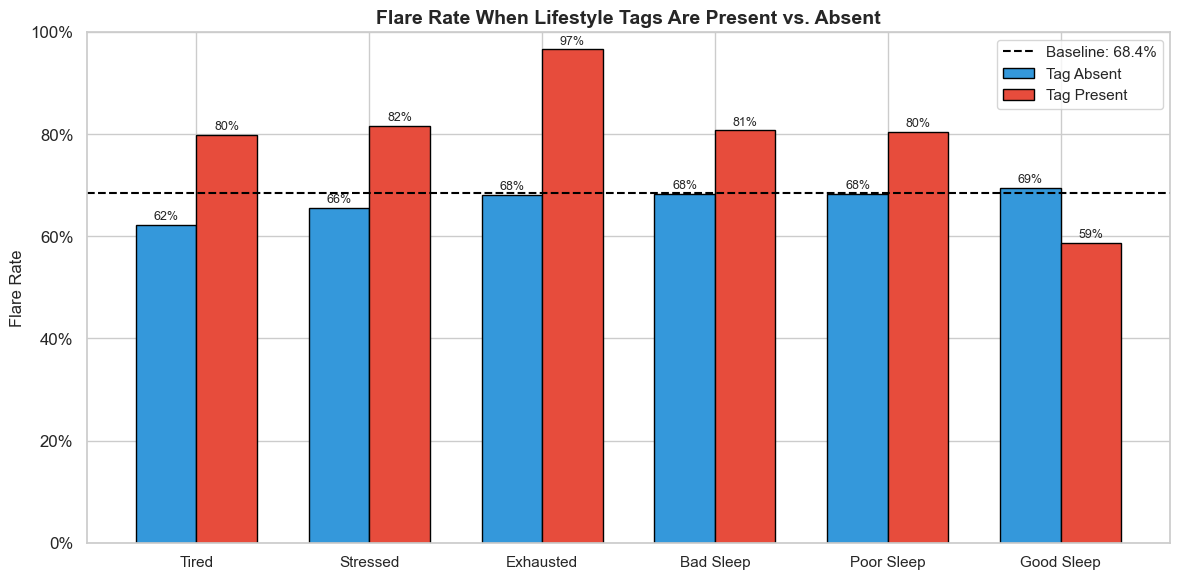

In [11]:
# Grouped Bar Chart — Flare Rate with Tag Present vs Absent
sig_tag_cols = ['tag_tired', 'tag_stressed', 'tag_exhausted', 
                'tag_bad_sleep', 'tag_poor_sleep', 'tag_good_sleep']
sig_tag_cols = [c for c in sig_tag_cols if c in feature_cols]

tag_names = []
present_rates = []
absent_rates = []

for col in sig_tag_cols:
    name = col.replace('tag_', '').replace('_', ' ').title()
    tag_names.append(name)
    present_rates.append(df[df[col] == 1]['flare'].mean())
    absent_rates.append(df[df[col] == 0]['flare'].mean())

x = np.arange(len(tag_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, absent_rates, width, label='Tag Absent', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, present_rates, width, label='Tag Present', color='#e74c3c', edgecolor='black')

ax.axhline(y=baseline_flare, color='black', linestyle='--', linewidth=1.5, label=f'Baseline: {baseline_flare:.1%}')
ax.set_ylabel('Flare Rate', fontsize=12)
ax.set_title('Flare Rate When Lifestyle Tags Are Present vs. Absent', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tag_names, fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'flare_rate_tag_present_absent.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** This grouped bar chart makes the magnitude of lifestyle effects viscerally clear. When users tag "Tired" or "Exhausted," their flare rate jumps dramatically compared to days without those tags. Conversely, "Good Sleep" is the only tag where being *present* is associated with a *lower* flare rate than when absent — making it the sole protective factor among the significant lifestyle tags. Note that this is a simple across-user comparison (not the within-user paired test from Section 1.3), so confounders may inflate the differences, but the direction is consistent with the rigorous analysis.

## 1.9 Compounding Effects: Tired + Stressed Together

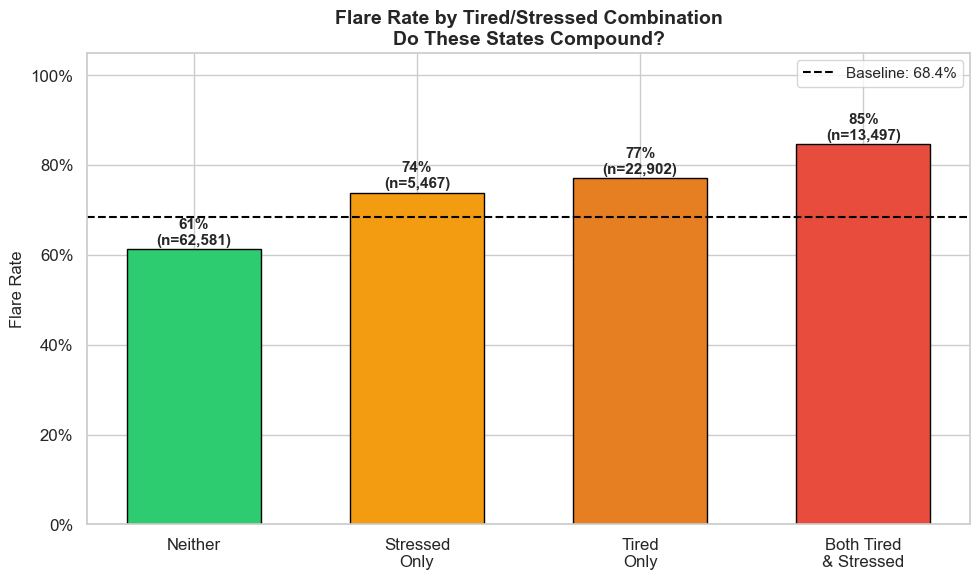

Neither:            61.3% (n=62,581)
Stressed only:      73.9% (n=5,467)
Tired only:         77.0% (n=22,902)
Both:               84.7% (n=13,497)
Baseline:           68.4%


In [12]:
# Compounding Effects: Tired + Stressed Together
from matplotlib.patches import Patch

combo_data = {
    'Neither': df[(df['tag_tired'] == 0) & (df['tag_stressed'] == 0)],
    'Stressed\nOnly': df[(df['tag_tired'] == 0) & (df['tag_stressed'] == 1)],
    'Tired\nOnly': df[(df['tag_tired'] == 1) & (df['tag_stressed'] == 0)],
    'Both Tired\n& Stressed': df[(df['tag_tired'] == 1) & (df['tag_stressed'] == 1)],
}

labels = list(combo_data.keys())
rates = [subset['flare'].mean() for subset in combo_data.values()]
counts = [len(subset) for subset in combo_data.values()]
colors_combo = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, rates, color=colors_combo, edgecolor='black', width=0.6)

for bar, rate, count in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.0%}\n(n={count:,})', ha='center', fontweight='bold', fontsize=11)

ax.axhline(y=baseline_flare, color='black', linestyle='--', linewidth=1.5,
           label=f'Baseline: {baseline_flare:.1%}')
ax.set_ylabel('Flare Rate', fontsize=12)
ax.set_title('Flare Rate by Tired/Stressed Combination\nDo These States Compound?',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tired_stressed_combo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Neither:            {rates[0]:.1%} (n={counts[0]:,})')
print(f'Stressed only:      {rates[1]:.1%} (n={counts[1]:,})')
print(f'Tired only:         {rates[2]:.1%} (n={counts[2]:,})')
print(f'Both:               {rates[3]:.1%} (n={counts[3]:,})')
print(f'Baseline:           {baseline_flare:.1%}')

**Interpretation:** This chart reveals an **interaction effect** between the two strongest flare predictors. When neither Tired nor Stressed is present, the flare rate drops well below baseline — these are genuinely "better" days. But when both appear on the same day, the flare rate spikes to its highest level, suggesting these states **compound** rather than simply adding together. This "bad day cluster" pattern — where fatigue, stress, and high symptoms pile up simultaneously — helps explain the strong Tired-Stressed correlation (+0.36) in the heatmap and why the ML models benefit from combining multiple signals.

---
# Part 2: Predictive Analytics (45 pts)

We train 5 models with `random_state=42`, 70/30 stratified split, and `class_weight='balanced'` to handle the class imbalance.

## 2.1 Scale Features

In [13]:
# StandardScaler for models that need it (Logistic Regression, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
print(f'Scaler fitted on {X_train_scaled.shape[1]} features')
print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Scaler fitted on 104 features
Train: (73112, 104) | Test: (31335, 104)


## 2.2 Model 1: Logistic Regression (Baseline)

In [14]:
# Logistic Regression — Baseline
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000, solver='lbfgs')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression Results:')
print(classification_report(y_test, y_pred_lr))
joblib.dump(lr, MODELS_DIR / 'logistic_regression.joblib')

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.43      0.67      0.52      9895
           1       0.79      0.59      0.68     21440

    accuracy                           0.62     31335
   macro avg       0.61      0.63      0.60     31335
weighted avg       0.68      0.62      0.63     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\logistic_regression.joblib']

## 2.3 Model 2: Decision Tree (with GridSearchCV)

In [15]:
# Decision Tree with GridSearchCV
dt_params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20, 50],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
y_prob_dt = dt_best.predict_proba(X_test)[:, 1]

print(f'Best params: {dt_grid.best_params_}')
print(f'Best CV F1: {dt_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_dt))
joblib.dump(dt_best, MODELS_DIR / 'decision_tree.joblib')

Best params: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 10}
Best CV F1: 0.7025
              precision    recall  f1-score   support

           0       0.46      0.66      0.54      9895
           1       0.81      0.65      0.72     21440

    accuracy                           0.65     31335
   macro avg       0.63      0.65      0.63     31335
weighted avg       0.70      0.65      0.66     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\decision_tree.joblib']

## 2.4 Model 3: Random Forest (with GridSearchCV)

In [16]:
# Random Forest with GridSearchCV
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV F1: {rf_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_rf))
joblib.dump(rf_best, MODELS_DIR / 'random_forest.joblib')

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.8253
              precision    recall  f1-score   support

           0       0.64      0.45      0.53      9895
           1       0.78      0.88      0.83     21440

    accuracy                           0.75     31335
   macro avg       0.71      0.67      0.68     31335
weighted avg       0.74      0.75      0.73     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\random_forest.joblib']

## 2.5 Model 4: XGBoost (with GridSearchCV)

In [17]:
# XGBoost with GridSearchCV
# Calculate scale_pos_weight for imbalanced classes
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos, 
                       use_label_encoder=False, eval_metric='logloss', verbosity=0),
    xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

print(f'Best params: {xgb_grid.best_params_}')
print(f'Best CV F1: {xgb_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_xgb))
joblib.dump(xgb_best, MODELS_DIR / 'xgboost.joblib')

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1: 0.7573
              precision    recall  f1-score   support

           0       0.52      0.68      0.59      9895
           1       0.83      0.71      0.76     21440

    accuracy                           0.70     31335
   macro avg       0.67      0.70      0.68     31335
weighted avg       0.73      0.70      0.71     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\xgboost.joblib']

## 2.6 Model 5: Neural Network — MLP (with GridSearchCV)

In [18]:
# MLP Neural Network with GridSearchCV
mlp_params = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01]
}
mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=500, early_stopping=True, 
                  validation_fraction=0.1),
    mlp_params, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
mlp_grid.fit(X_train_scaled, y_train)
mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_scaled)
y_prob_mlp = mlp_best.predict_proba(X_test_scaled)[:, 1]

print(f'Best params: {mlp_grid.best_params_}')
print(f'Best CV F1: {mlp_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_mlp))
joblib.dump(mlp_best, MODELS_DIR / 'mlp_neural_net.joblib')

Best params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32)}
Best CV F1: 0.8181
              precision    recall  f1-score   support

           0       0.62      0.31      0.41      9895
           1       0.74      0.91      0.82     21440

    accuracy                           0.72     31335
   macro avg       0.68      0.61      0.62     31335
weighted avg       0.70      0.72      0.69     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\mlp_neural_net.joblib']

## 2.7 Model Comparison

In [19]:
# Model Comparison Table
models_info = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'Neural Network (MLP)': (y_pred_mlp, y_prob_mlp)
}

comparison = []
for name, (y_pred, y_prob) in models_info.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

comp_df = pd.DataFrame(comparison).set_index('Model')
comp_df = comp_df.round(4)

# Save for Streamlit
comp_df.to_csv(DATA_DIR / 'model_comparison.csv')

# Style and display
styled = comp_df.style.highlight_max(axis=0, color='lightgreen')
display(styled)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.615500,0.794600,0.590800,0.677700,0.685700
Decision Tree,0.651800,0.805100,0.647900,0.718000,0.713600
Random Forest,0.748500,0.778200,0.884500,0.827900,0.772500
XGBoost,0.699200,0.828900,0.706100,0.762600,0.770600
Neural Network (MLP),0.721400,0.741300,0.910500,0.817300,0.712100


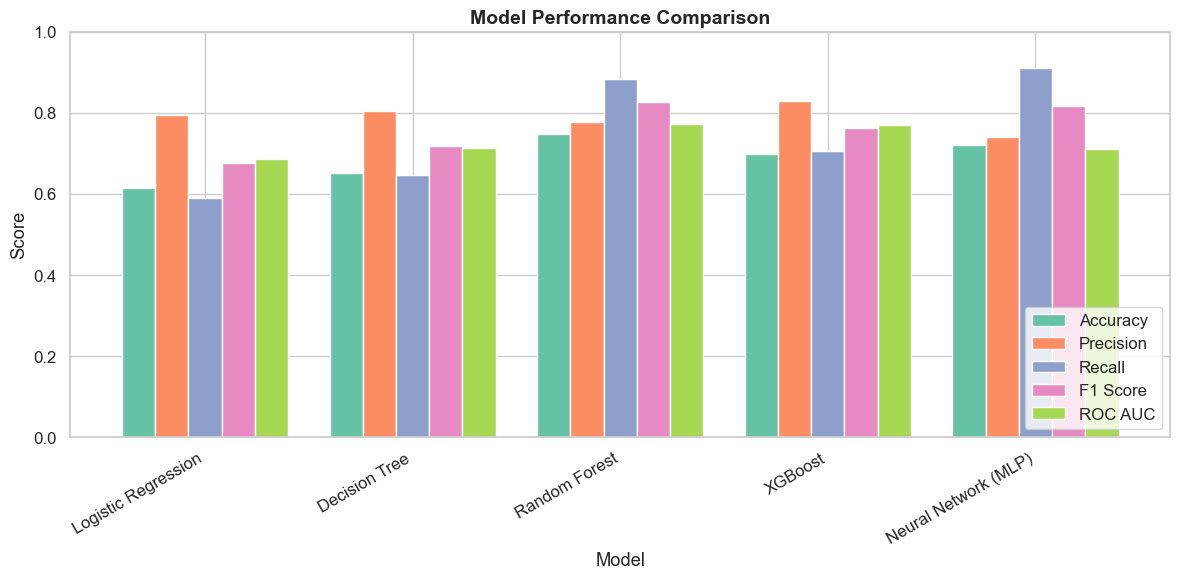

In [20]:
# Bar Chart Comparison
fig, ax = plt.subplots(figsize=(12, 6))
comp_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

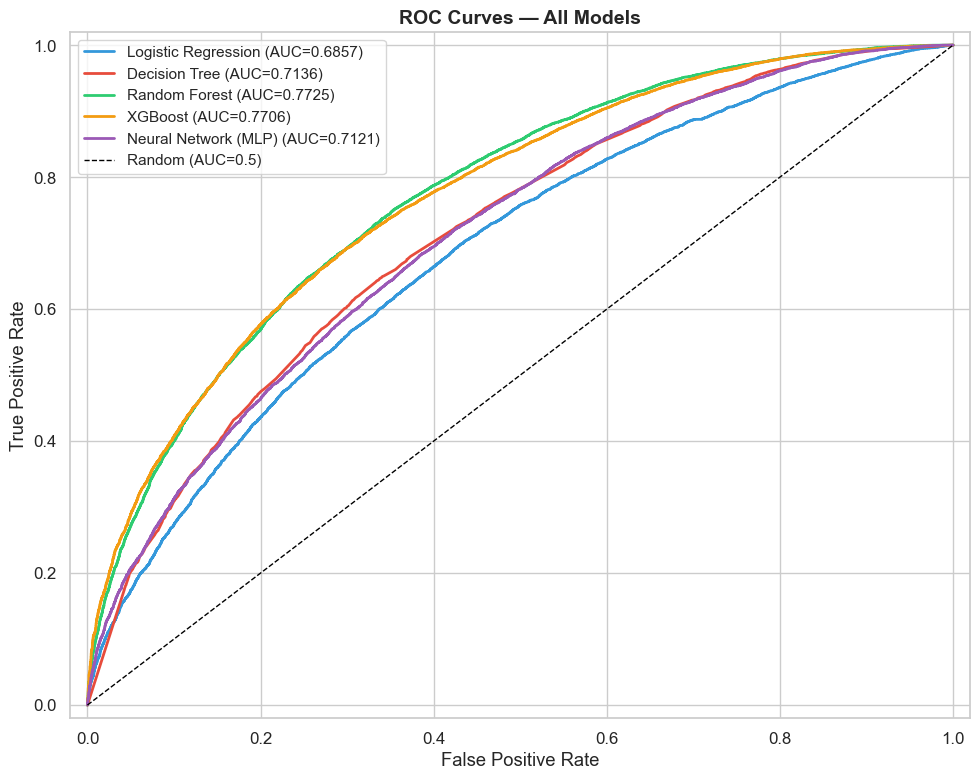

In [21]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for (name, (_, y_prob)), color in zip(models_info.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Best model by F1: Random Forest


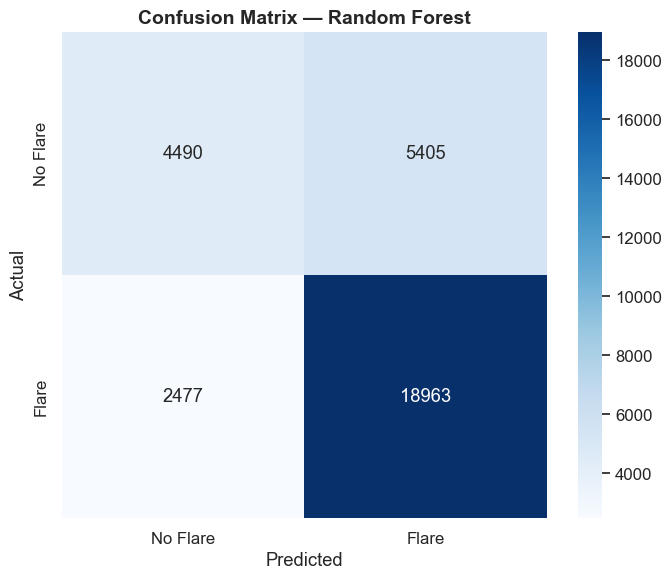

In [22]:
# Confusion Matrix for Best Model
best_model_name = comp_df['F1 Score'].idxmax()
best_pred = models_info[best_model_name][0]
print(f'Best model by F1: {best_model_name}')

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Flare', 'Flare'], yticklabels=['No Flare', 'Flare'])
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: Explainability with SHAP (10 pts)

We use SHAP (SHapley Additive exPlanations) on the best tree-based model to understand which features drive predictions.

In [23]:
# SHAP Analysis on XGBoost (best tree-based model)
# Use XGBoost regardless of which model scored highest, since SHAP TreeExplainer is most reliable
explainer = shap.TreeExplainer(xgb_best)

# Compute SHAP values on test set (sample for speed)
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# Clean feature names for display
clean_names = [c.replace('food_', '').replace('treat_', 'Tx:').replace('tag_', 'Tag:').replace('weather_', 'W:').replace('foodcat_', 'Cat:').replace('_', ' ').title() for c in feature_cols]
shap_sample_display = shap_sample.copy()
shap_sample_display.columns = clean_names

print(f'SHAP values computed for {len(shap_sample)} samples')

SHAP values computed for 2000 samples


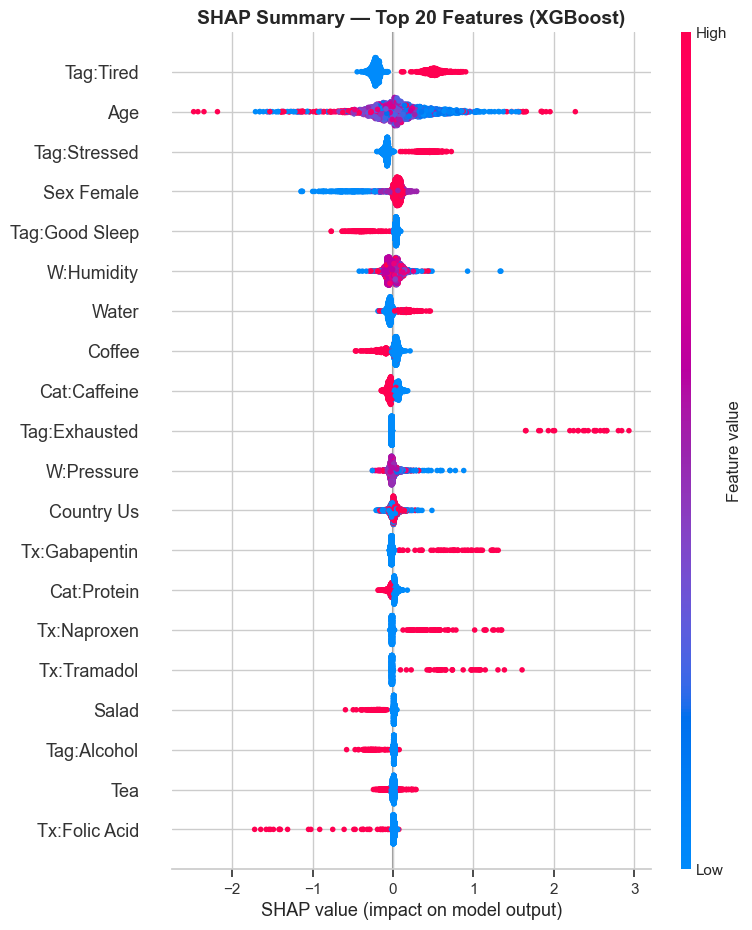

In [24]:
# SHAP Summary Plot (Beeswarm)
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, shap_sample_display, max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Features (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

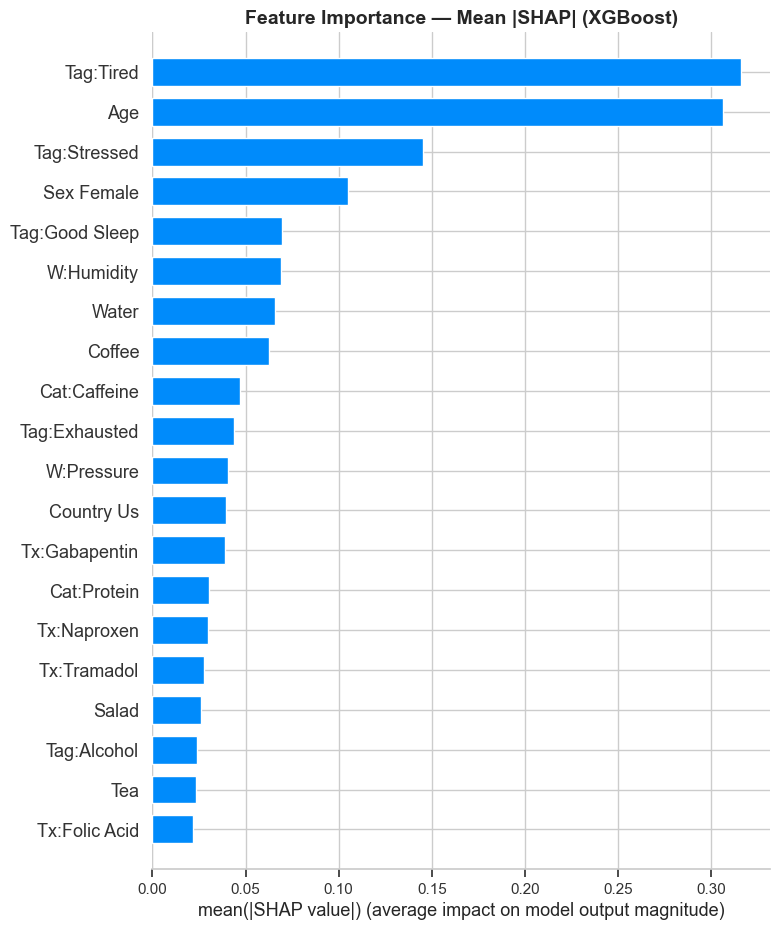

In [25]:
# SHAP Bar Plot (Mean Absolute SHAP Values)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample_display, plot_type='bar', max_display=20, show=False)
plt.title('Feature Importance — Mean |SHAP| (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

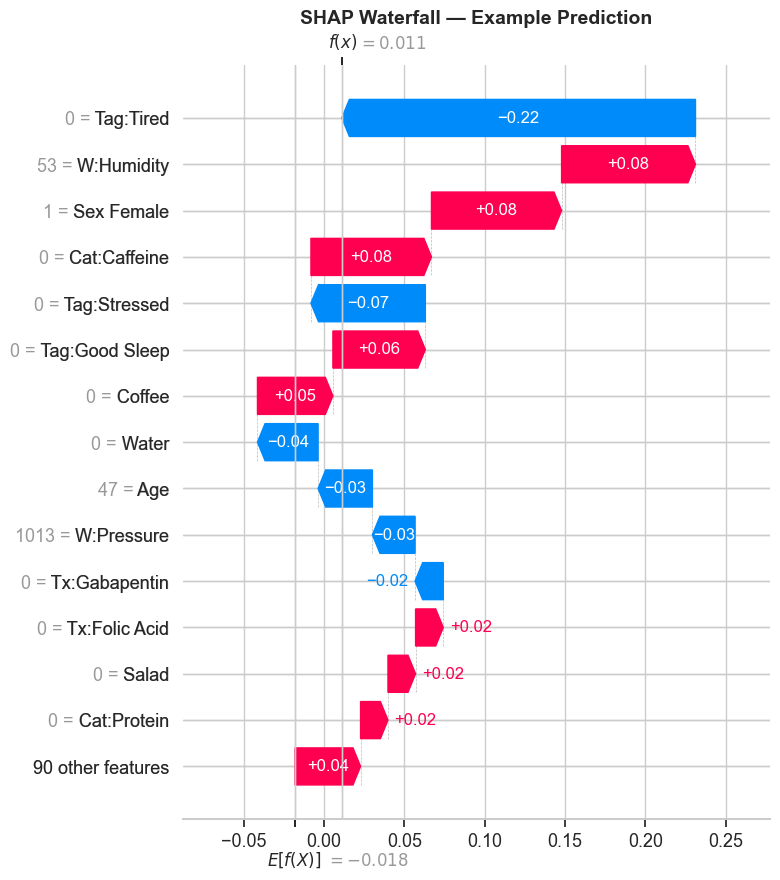

In [26]:
# SHAP Waterfall Plot — Single Prediction Example
# Pick a flare=1 example from test set
flare_indices = y_test[y_test == 1].index
sample_idx = shap_sample.index[0]

explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=shap_sample_display.iloc[0],
    feature_names=clean_names
)

fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Example Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

### The Story: From Food to Lifestyle

This project began with a personal question: *as someone with hEDS and POTS, which foods trigger my flares?* The journey to answering it revealed something more important.

**Step 1 — Naive analysis was misleading.** A simple comparison of flare rates by food showed alcohol and milk as "protective" and veggies as "harmful." This was entirely due to **Simpson's Paradox** — different users have different baseline flare rates, and *who* tracks a food matters more than *what* they eat.

**Step 2 — Within-user analysis found no reliable food effects.** Comparing the same users' flare rates on eating vs. non-eating days, and correcting for 50 simultaneous tests (Bonferroni), **zero individual foods** showed a statistically significant effect on flares.

**Step 3 — Lifestyle factors showed massive, robust effects.** The same methodology applied to lifestyle tags found **6 highly significant factors** (all surviving strict Bonferroni correction):

| Factor | Effect on Flare Rate | p-value | Users |
|--------|---------------------|---------|-------|
| Good Sleep | -12.6% (protective) | p < 0.000001 | 572 |
| Stressed | +11.9% (trigger) | p < 0.000001 | 968 |
| Tired | +17.4% (trigger) | p < 0.000001 | 1,264 |
| Exhausted | +20.8% (trigger) | p = 0.000023 | 58 |
| Poor Sleep | +6.7% (trigger) | p = 0.000225 | 71 |
| Bad Sleep | +5.5% (trigger) | p = 0.000631 | 108 |

### Why the ML Models Still Work

The predictive models achieve ~77% ROC AUC despite no single food being significant. This is because:
- The models combine **many weak food signals** with **strong lifestyle signals** (tags, treatments, weather)
- SHAP analysis confirms that tags like stress, sleep quality, and exhaustion are among the top predictors
- Individual food features have small SHAP values, consistent with the statistical finding

### Important Limitations
1. **Correlation, not causation.** People may log "stressed" on already-bad days.
2. **Self-reporting bias.** Tracking behavior itself varies with how people feel.
3. **Food effects may be individual.** Population averages wash out person-specific triggers — your triggers may differ from the average.
4. **Small per-food sample sizes.** Most foods are tracked by only 50-500 users with sufficient data.

### Practical Takeaways for Chronic Illness Patients
1. **Prioritize stress management and sleep** — these show the largest, most reliable effects on flares
2. **Don't obsess over individual foods** — at a population level, no single food reliably triggers or prevents flares
3. **Track YOUR patterns** — individual triggers may exist even if they don't show up in population data
4. **Discuss changes with your healthcare provider** — data is a starting point for conversation, not a prescription

In [27]:
# Save SHAP values for Streamlit app
np.save(DATA_DIR / 'shap_values.npy', shap_values)
shap_sample.to_parquet(DATA_DIR / 'shap_sample.parquet')
np.save(DATA_DIR / 'shap_expected_value.npy', np.array([explainer.expected_value]))
print('SHAP data saved for Streamlit app.')
print('\n=== ANALYSIS COMPLETE ===')

SHAP data saved for Streamlit app.

=== ANALYSIS COMPLETE ===
